# Experiment: Classification and Regression Tasks

## Task 1: Perform Classification Task on Titanic Dataset

In [1]:
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

In [6]:
titanic_df = pd.read_csv(titanic_url)

In [7]:
titanic_features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked'
]

In [8]:
X_titanic = titanic_df[titanic_features]

In [9]:
y_titanic = titanic_df['Survived']

In [10]:
X_titanic['Age'] = X_titanic['Age'].fillna(
    X_titanic['Age'].median()
)

In [11]:
X_titanic['Embarked'] = X_titanic['Embarked'].fillna(
    X_titanic['Embarked'].mode()[0]
)

In [12]:
X_titanic = pd.get_dummies(
    X_titanic,
    columns=['Sex', 'Embarked'],
    drop_first=True
)

In [13]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_titanic,
    y_titanic,
    test_size=0.20,
    stratify=y_titanic,
    random_state=42
)

In [14]:
print("Titanic Classification Training Set Shape:", X_train_c.shape)
print("Titanic Classification Test Set Shape:", X_test_c.shape)

Titanic Classification Training Set Shape: (712, 8)
Titanic Classification Test Set Shape: (179, 8)


In [15]:
from sklearn.tree import DecisionTreeClassifier

In [16]:
from sklearn.metrics import accuracy_score, classification_report

In [17]:
tree_clf = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

In [18]:
tree_clf.fit(X_train_c, y_train_c)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [19]:
clf_preds = tree_clf.predict(X_test_c)

In [20]:
print(
    f"Decision Tree Classifier Test Accuracy: "
    f"{accuracy_score(y_test_c, clf_preds) * 100:.2f}%\n"
)

Decision Tree Classifier Test Accuracy: 78.77%



In [21]:
print("--- Classification Report ---")

print(
    classification_report(
        y_test_c,
        clf_preds,
        target_names=['Not Survived (0)', 'Survived (1)']
    )
)

--- Classification Report ---
                  precision    recall  f1-score   support

Not Survived (0)       0.77      0.94      0.84       110
    Survived (1)       0.84      0.55      0.67        69

        accuracy                           0.79       179
       macro avg       0.81      0.74      0.76       179
    weighted avg       0.80      0.79      0.78       179



In [22]:
import matplotlib.pyplot as plt

In [25]:
from sklearn.tree import plot_tree

In [26]:
plt.figure(figsize=(15, 8))

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

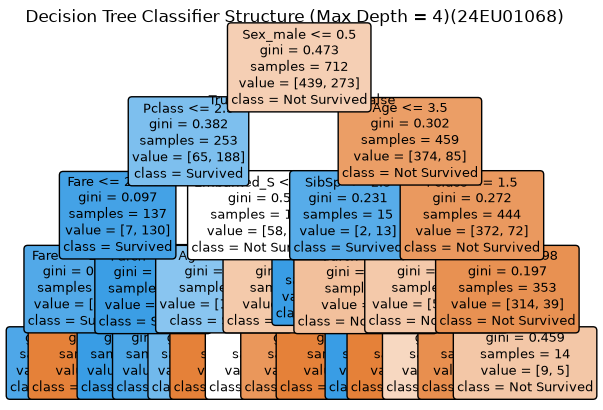

In [27]:
plot_tree(
    tree_clf,
    feature_names=X_titanic.columns,
    class_names=['Not Survived', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title(
    "Decision Tree Classifier Structure (Max Depth = 4)(24EU01068)"
)
plt.show()

## Task 2: Perform Regression Task on California Housing Dataset

In [28]:
import warnings

In [29]:
warnings.filterwarnings("ignore")

In [30]:
from sklearn.datasets import fetch_california_housing

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
california = fetch_california_housing()

In [33]:
california_df = pd.DataFrame(
    california.data,
    columns=california.feature_names
)

In [34]:
california_df['MedHouseVal'] = california.target

In [35]:
california_features = california.feature_names

In [36]:
X_california = california_df[california_features]

In [37]:
y_california = california_df['MedHouseVal']

In [38]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_california,
    y_california,
    test_size=0.20,
    random_state=42
)

In [39]:
print(
    "California Housing Regression Training Set Shape:",
    X_train_r.shape
)

print(
    "California Housing Regression Test Set Shape:",
    X_test_r.shape
)

California Housing Regression Training Set Shape: (16512, 8)
California Housing Regression Test Set Shape: (4128, 8)


In [40]:
from sklearn.preprocessing import StandardScaler

In [41]:
scaler_r = StandardScaler()

In [42]:
X_train_r_scaled = scaler_r.fit_transform(X_train_r)

In [43]:
X_test_r_scaled = scaler_r.transform(X_test_r)

In [44]:
from sklearn.tree import DecisionTreeRegressor

In [45]:
tree_reg = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

In [46]:
tree_reg.fit(
    X_train_r_scaled,
    y_train_r
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [47]:
print(
    "Decision Tree Regressor trained successfully. "
    "Max Depth set to 5."
)

Decision Tree Regressor trained successfully. Max Depth set to 5.


In [48]:
from sklearn.metrics import mean_squared_error, r2_score

In [49]:
import numpy as np

In [50]:
reg_preds = tree_reg.predict(X_test_r_scaled)

In [51]:
mse = mean_squared_error(y_test_r, reg_preds)

In [52]:
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, reg_preds)

In [53]:
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R2 Coefficient of Determination: {r2:.4f}")

Mean Squared Error (MSE): 0.5245
Root Mean Squared Error (RMSE): 0.7242
R2 Coefficient of Determination: 0.5997


In [54]:
import matplotlib.pyplot as plt

In [55]:
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

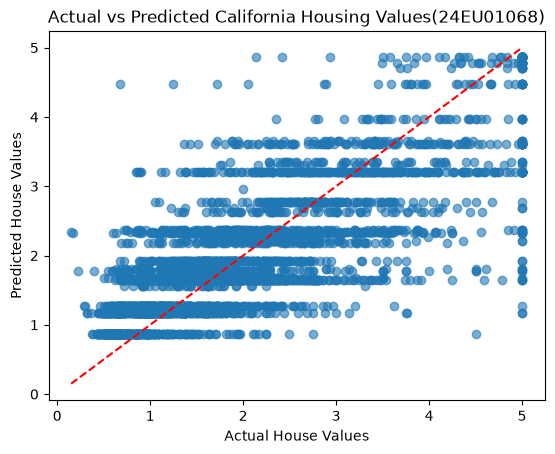

In [57]:
plt.scatter(
    y_test_r,
    reg_preds,
    alpha=0.6
)

plt.xlabel("Actual House Values")
plt.ylabel("Predicted House Values")

plt.title(
    "Actual vs Predicted California Housing Values(24EU01068)"
)

# Reference line
plt.plot(
    [y_test_r.min(), y_test_r.max()],
    [y_test_r.min(), y_test_r.max()],
    'r--'
)

plt.show()